## 1. Environment & imports

In [15]:
# Standard imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Dataset & DataLoader

In [16]:
# Image size
IMG_SIZE = 224  # ResNet standard input

# Data augmentation & preprocessing
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean
                         [0.229, 0.224, 0.225])  # ImageNet std
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset paths
train_dir = "dataset_processed/train"
val_dir = "dataset_processed/val"
test_dir = "dataset_processed/test"

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

# DataLoaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")


Train size: 1400, Val size: 320, Test size: 1280


## 3. Define ResNet50 Model

In [17]:
# Load pretrained ResNet50
resnet50 = models.resnet50(pretrained=True)

# Freeze all layers initially (optional)
for param in resnet50.parameters():
    param.requires_grad = True  # For fine-tuning, set True; if just last layer, freeze rest

# Modify final fully connected layer
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, 2)  # Binary classification

# Move to device
resnet50 = resnet50.to(device)


c:\Users\mohdf\OneDrive - Singapore Institute Of Technology\Capstone\Project\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mohdf\OneDrive - Singapore Institute Of Technology\Capstone\Project\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 4. Loss, Optimizer & Scheduler

In [18]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(resnet50.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


## 5. Training Loop


Epoch 1/25


Validation: 100%|██████████| 20/20 [00:10<00:00,  1.84it/s]


Train Loss: 0.2160 | Train Acc: 0.9171
Val Loss: 0.0660 | Val Acc: 0.9781 | Val AUC: 0.9979
✅ Saved best model with val_loss: 0.0660

Epoch 2/25


Validation: 100%|██████████| 20/20 [00:10<00:00,  1.95it/s]


Train Loss: 0.1009 | Train Acc: 0.9650
Val Loss: 0.0179 | Val Acc: 0.9969 | Val AUC: 1.0000
✅ Saved best model with val_loss: 0.0179

Epoch 3/25


...

Train Loss: 0.0116 | Train Acc: 0.9957
Val Loss: 0.0460 | Val Acc: 0.9906 | Val AUC: 0.9957

Epoch 12/25


Validation: 100%|██████████| 20/20 [00:10<00:00,  1.95it/s]


Train Loss: 0.0065 | Train Acc: 0.9993
Val Loss: 0.0319 | Val Acc: 0.9906 | Val AUC: 0.9990

Epoch 13/25


Validation: 100%|██████████| 20/20 [00:12<00:00,  1.62it/s]

Train Loss: 0.0067 | Train Acc: 0.9986
Val Loss: 0.0618 | Val Acc: 0.9938 | Val AUC: 0.9953
⏹️ Early stopping triggered.


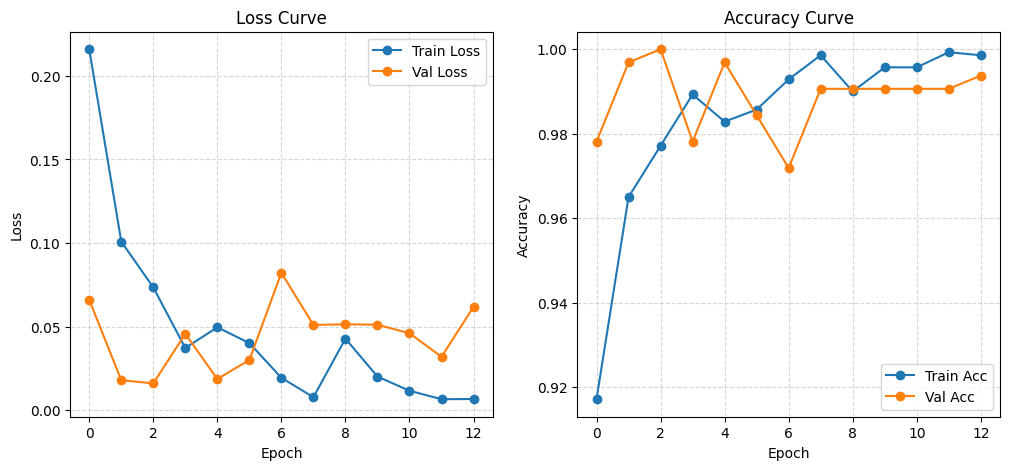

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# Training configuration
EPOCHS = 25
best_val_loss = np.inf
early_stop_counter = 0
PATIENCE = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    # ----- TRAIN -----
    resnet50.train()
    running_loss, correct, total = 0, 0, 0
    
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # ----- VALIDATION -----
    resnet50.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_labels, all_preds = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(outputs.softmax(dim=1)[:, 1].cpu().numpy())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Scheduler and early stopping
    scheduler.step(val_loss)
    
    val_auc = roc_auc_score(all_labels, all_preds)
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet50.state_dict(), "resnet50_best.pth")
        print(f"✅ Saved best model with val_loss: {best_val_loss:.4f}")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("⏹️ Early stopping triggered.")
            break

# ---------- Visualization ----------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc', marker='o')
plt.plot(val_accuracies, label='Val Acc', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 6. Evaluate on Test Set

Testing: 100%|██████████| 80/80 [00:39<00:00,  2.00it/s]

Test Accuracy: 0.9992
Test AUC: 1.0000

Confusion Matrix:
 [[640   0]
 [  1 639]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9984    1.0000    0.9992       640
           1     1.0000    0.9984    0.9992       640

    accuracy                         0.9992      1280
   macro avg     0.9992    0.9992    0.9992      1280
weighted avg     0.9992    0.9992    0.9992      1280



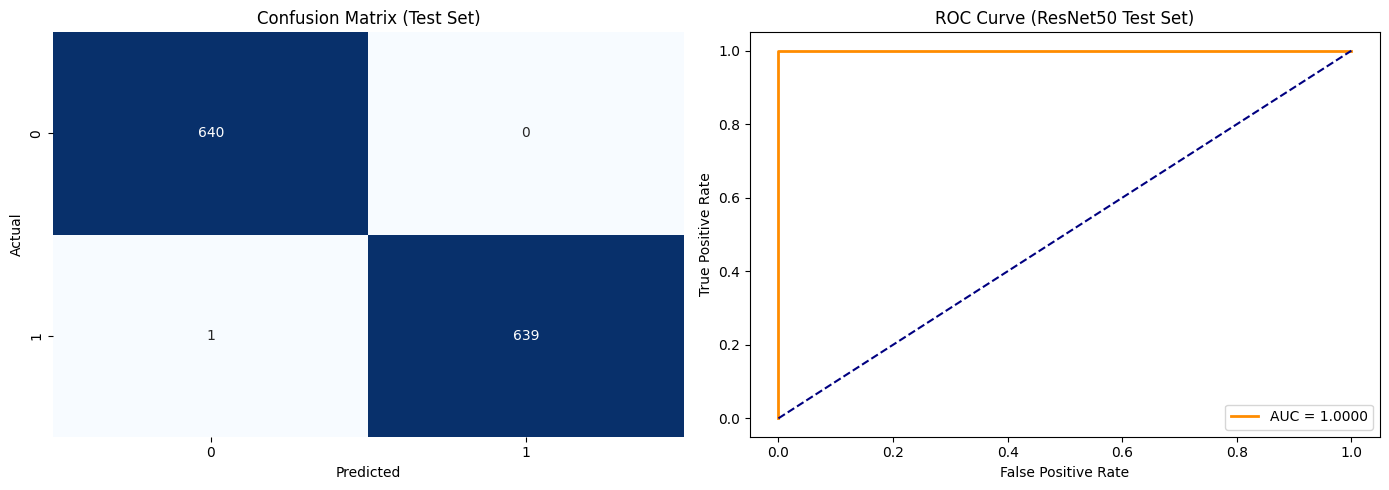

In [20]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
import pandas as pd
import numpy as np

# Load best model
resnet50.load_state_dict(torch.load("resnet50_best.pth"))
resnet50.eval()

all_labels, all_preds_class, all_preds_prob = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        probs = outputs.softmax(dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds_class.extend(preds.cpu().numpy())
        all_preds_prob.extend(probs[:,1].cpu().numpy())

# Compute metrics
acc = accuracy_score(all_labels, all_preds_class)
auc_score = roc_auc_score(all_labels, all_preds_prob)
conf_mat = confusion_matrix(all_labels, all_preds_class)
report = classification_report(all_labels, all_preds_class, digits=4)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC: {auc_score:.4f}")
print("\nConfusion Matrix:\n", conf_mat)
print("\nClassification Report:\n", report)

# Save predictions
pd.DataFrame({
    "label": all_labels,
    "pred_class": all_preds_class,
    "pred_prob": all_preds_prob
}).to_csv("resnet50_test_predictions.csv", index=False)

# ---------- Visualization ----------
plt.figure(figsize=(14,5))

# Confusion Matrix
plt.subplot(1,2,1)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_preds_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1,2,2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (ResNet50 Test Set)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


ResNet50, fine-tuned on the processed brain MRI dataset, achieved near-perfect classification performance with 99.9% test accuracy and an AUC of 1.0. Early stopping occurred at epoch 13, indicating rapid convergence. The model demonstrates superior feature extraction compared to a baseline CNN and generalizes effectively to the test set, making it an excellent candidate for downstream analysis and reporting.